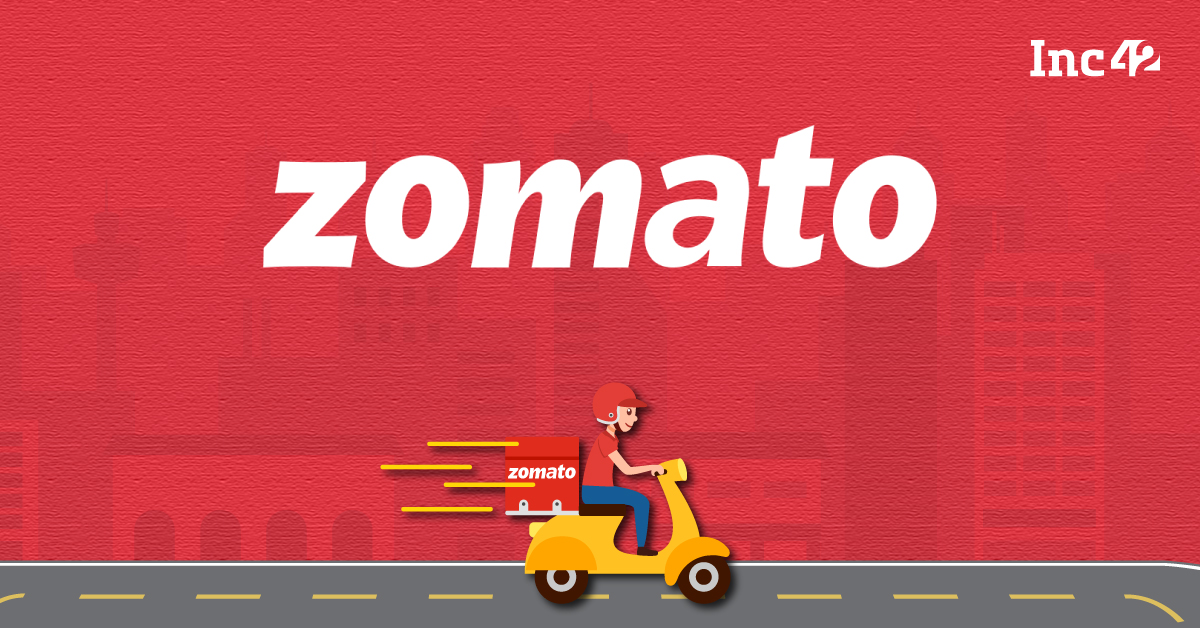

In [169]:
from IPython.display import Image
Image("ZomatoCompany.jpg")

# EXPLORATORY DATA ANALYSIS (EDA) ON Zomato Dataset:

In [170]:
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("zomato.csv")

## Columns description

- **url:** contains the url of the restaurant in the zomato website
- **address:** contains the address of the restaurant in Bengaluru
- **name:** contains the name of the restaurant
- **online_order:** whether online ordering is available in the restaurant or not
- **book_table:** table book option available or not
- **rate:** contains the overall rating of the restaurant out of 5
- **votes:** contains total number of rating for the restaurant as of the above mentioned date
- **phone:** contains the phone number of the restaurant
- **location:** contains the neighborhood in which the restaurant is located
- **rest_type:** restaurant type
- **dish_liked:** dishes people liked in the restaurant
- **cuisines:** food styles, separated by comma
- **approx_cost(for two people):** contains the approximate cost for meal for two people
- **reviews_list:** list of tuples containing reviews for the restaurant, each tuple
- **menu_item:** contains list of menus available in the restaurant
- **listed_in(type):** type of meal
- **listed_in(city):** contains the neighborhood in which the restaurant is listed

# _DATA CLEANING PART_ :

In [171]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [172]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [174]:
df.shape

(51717, 17)

In [175]:
df["rate"] = df["rate"].fillna("0/5")
df["dish_liked"] = df["dish_liked"].fillna("0/5")
df.dropna(subset=["phone","location","dish_liked","rest_type","approx_cost(for two people)","cuisines"],inplace=True)
df = df.drop(columns=["listed_in(city)"])

In [176]:
df.shape

(50279, 16)

In [177]:
df.isnull().sum()

url                            0
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
dtype: int64

In [178]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

def clean_phone(cell):
    if pd.isna(cell):
        return ''
    # Split by line breaks
    numbers = re.split(r'\r\n|\n', cell)
    cleaned_numbers = []
    for num in numbers:
        # Remove spaces, keep only digits
        num = re.sub(r'\D', '', num)
        cleaned_numbers.append(num)
    # Return as list if multiple, or first number only
    return cleaned_numbers[0] if len(cleaned_numbers) > 1 else cleaned_numbers[0]

# Apply cleaning
df['phone'] = df['phone'].apply(clean_phone)


In [179]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,08042297555,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,08041714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,919663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,919620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,918026612447,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet


In [180]:
df.dtypes

url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
dtype: object

In [181]:
df["rate"] = pd.to_numeric(df["rate"], errors='coerce')
df["phone"] = df["phone"].astype(int)
# Remove commas and convert to int
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "").astype(int)
df['dish_liked'] = df['dish_liked'].apply(lambda x: x.split(',')[0] if x !='Unknown' else 'Unknown')
df['cuisines'] = df['cuisines'].apply(lambda x: x.split(',')[0] if x !='Unknown' else 'Unknown')
df['rest_type'] = df['rest_type'].apply(lambda x: x.split(',')[0] if x !='Unknown' else 'Unknown')



In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50279 entries, 0 to 51716
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          50279 non-null  object 
 1   address                      50279 non-null  object 
 2   name                         50279 non-null  object 
 3   online_order                 50279 non-null  object 
 4   book_table                   50279 non-null  object 
 5   rate                         48022 non-null  float64
 6   votes                        50279 non-null  int64  
 7   phone                        50279 non-null  int64  
 8   location                     50279 non-null  object 
 9   rest_type                    50279 non-null  object 
 10  dish_liked                   50279 non-null  object 
 11  cuisines                     50279 non-null  object 
 12  approx_cost(for two people)  50279 non-null  int64  
 13  reviews_list         

# EDA (Exploratory Data Analysis) QUESTIONS:

In [183]:
#Places from where we are getting most orders:
df["location"].value_counts().reset_index(name="No. of orders").head(5)

,location,No. of orders
0,BTM,4981
1,HSR,2479
2,Koramangala 5th Block,2446
3,JP Nagar,2200
4,Whitefield,2079


In [184]:
#Places from where we are getting low orders:
df["location"].value_counts().reset_index(name="No. of orders").sort_values(by="No. of orders",ascending=True).head(5)

,location,No. of orders
92,Peenya,1
91,Rajarajeshwari Nagar,2
90,Jakkur,3
89,Yelahanka,5
87,West Bangalore,6


In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

In [186]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,8042297555,Banashankari,Casual Dining,Pasta,North Indian,800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,8041714161,Banashankari,Casual Dining,Momos,Chinese,800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,919663487993,Banashankari,Cafe,Churros,Cafe,800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,919620009302,Banashankari,Quick Bites,Masala Dosa,South Indian,300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,918026612447,Basavanagudi,Casual Dining,Panipuri,North Indian,600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet


### EDA QUESTION 1] Show the locations from where most orders were made:

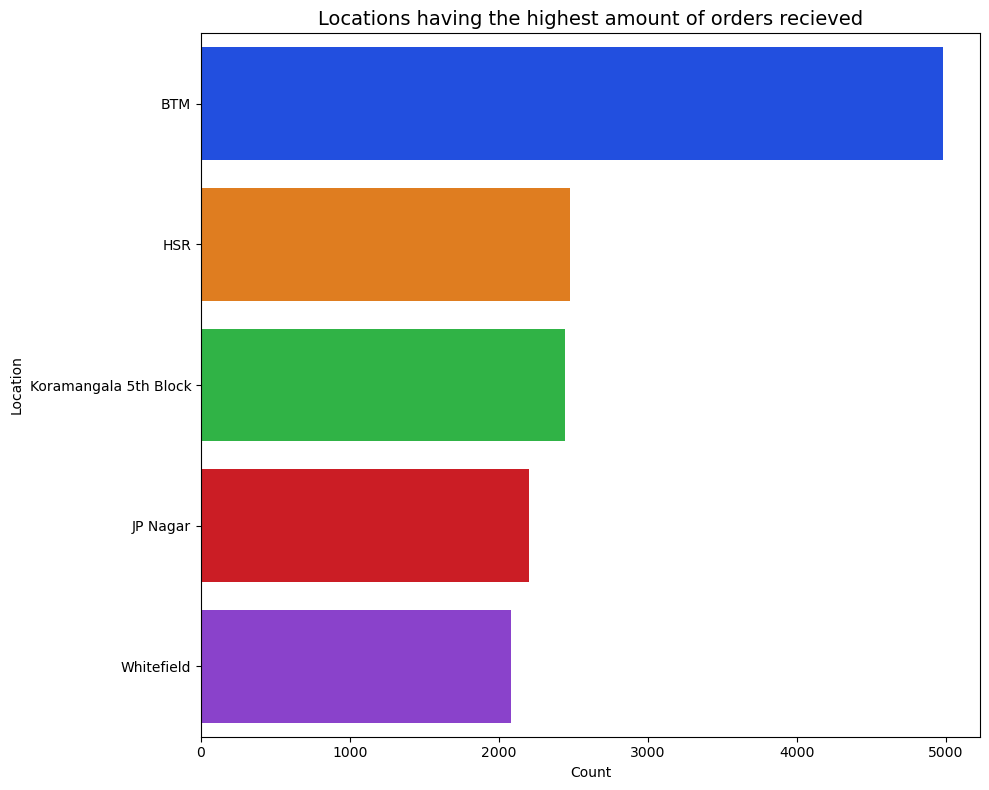

In [187]:
plt.figure(figsize=(10,8))
data = df["location"].value_counts().reset_index(name="No. of orders").head(5)
sns.barplot(
    x="No. of orders",
    y="location",
    data=data,
    palette="bright"
)

plt.title("Locations having the highest amount of orders recieved", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Location")

plt.tight_layout()
plt.show()


### EDA QUESTION 2] Show how many people placed their orders online and how many not:

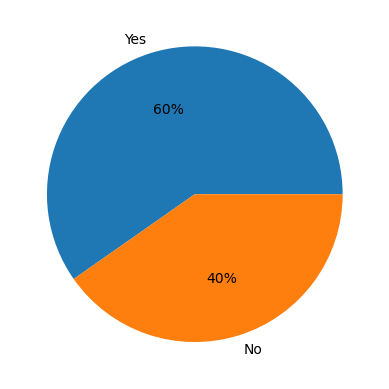

In [188]:
counts = df["online_order"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.0f%%')
plt.show()

### EDA QUESTION 3] Show how many people booked a table and how many not:

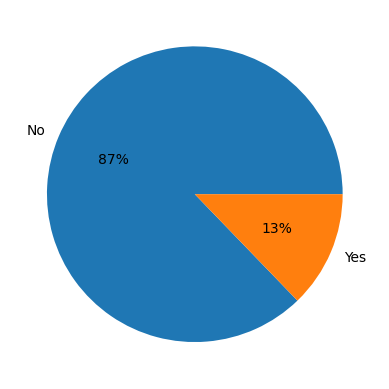

In [189]:
counts = df["book_table"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.0f%%')
plt.show()

### EDA QUESTION 4] Show top 5 cusines:

In [190]:
plt.figure(figsize=(10,8))
data=df.value_counts("cuisines").reset_index().head(5)
data

,cuisines,count
0,North Indian,11957
1,South Indian,4840
2,Cafe,4204
3,Chinese,3029
4,Biryani,2975


<Figure size 1000x800 with 0 Axes>

### _visualize the above result:_

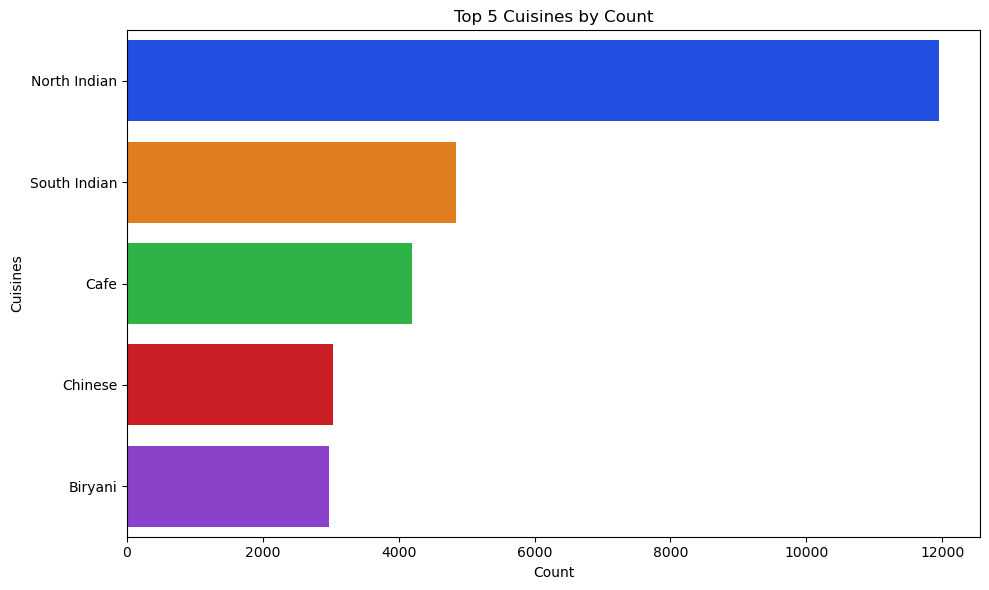

In [191]:
plt.figure(figsize=(10, 6))
sns.barplot(y="cuisines", x="count", data=data.head(5), palette="bright")

plt.xlabel("Count")
plt.ylabel("Cuisines")
plt.title("Top 5 Cuisines by Count")

plt.tight_layout()
plt.show()


### EDA QUESTION 5] Show top 5 cusines' category:

<Figure size 1000x800 with 0 Axes>

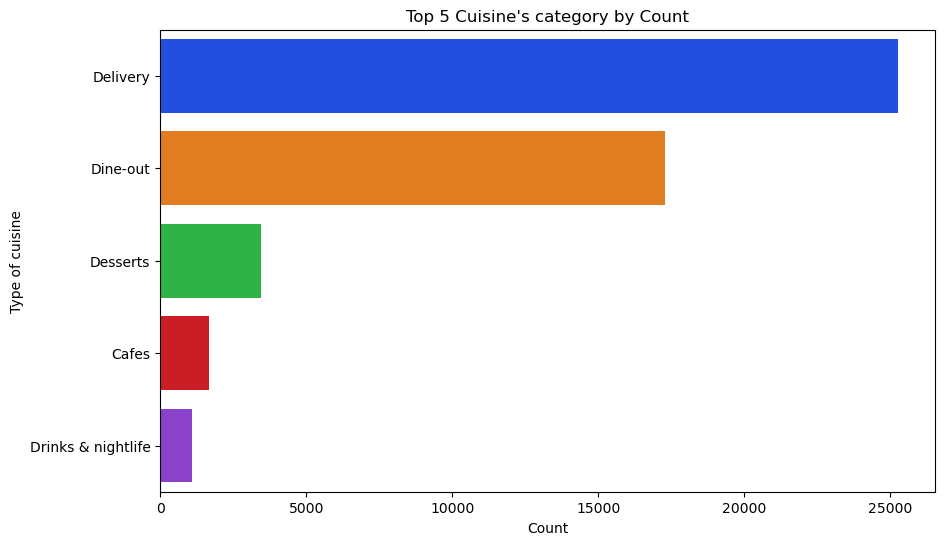

In [192]:
plt.figure(figsize=(10,8))
data = df.value_counts("listed_in(type)").reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    y="listed_in(type)", 
    x="count", 
    data=data.head(5),
    palette="bright"
)

plt.xlabel("Count")
plt.ylabel("Type of cuisine")
plt.title("Top 5 Cuisine's category by Count")

plt.show()


### EDA QUESTION 6] Show the cities having the most placed orders:

<Figure size 1000x800 with 0 Axes>

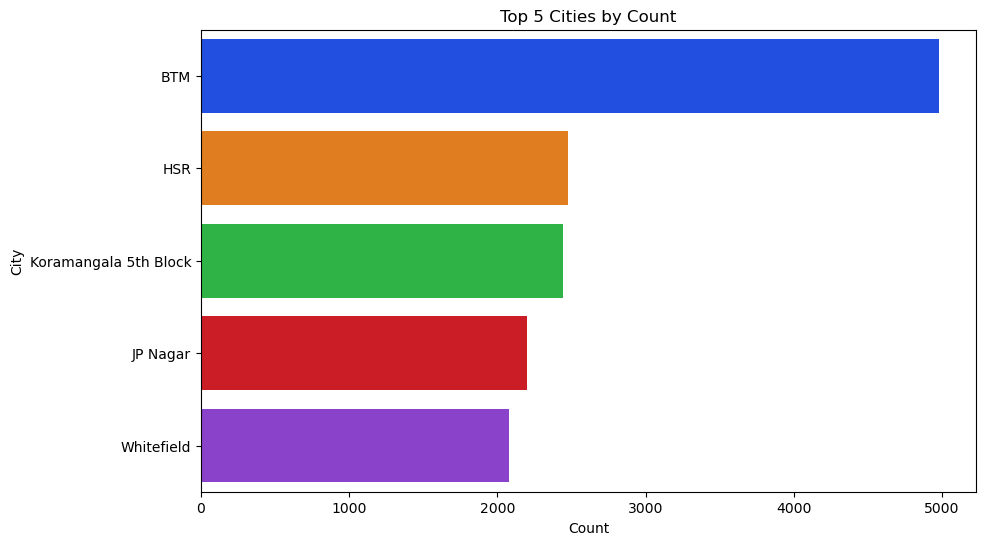

In [193]:
plt.figure(figsize=(10,8))
data = df.value_counts("location").reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    y="location", 
    x="count", 
    data=data.head(5),
    palette="bright"
)

plt.xlabel("Count")
plt.ylabel("City")
plt.title("Top 5 Cities by Count")

plt.show()

### EDA QUESTION 7] Show the top 5 restaurant-types preferred:

<Figure size 1000x800 with 0 Axes>

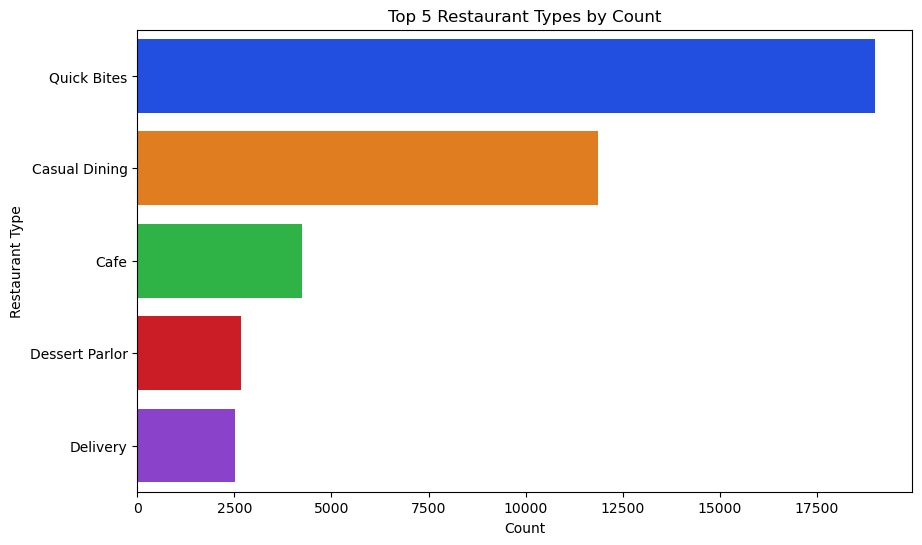

In [194]:
plt.figure(figsize=(10,8))
data = df.value_counts("rest_type").reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    y="rest_type", 
    x="count", 
    data=data.head(5),
    palette="bright"
)

plt.xlabel("Count")
plt.ylabel("Restaurant Type")
plt.title("Top 5 Restaurant Types by Count")

plt.show()

In [195]:
df.isnull().sum()

url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                           2257
votes                             0
phone                             0
location                          0
rest_type                         0
dish_liked                        0
cuisines                          0
approx_cost(for two people)       0
reviews_list                      0
menu_item                         0
listed_in(type)                   0
dtype: int64

In [196]:
df["rate"] = df["rate"].fillna(0.0)

In [197]:
data = df["rate"].value_counts().reset_index().head()

### EDA QUESTION 8] Show the most often ratings given:

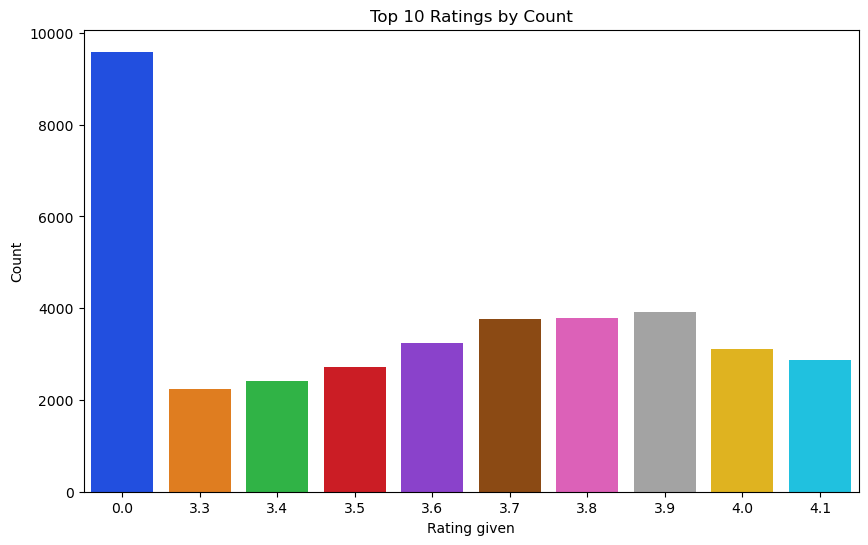

In [198]:
data = df.value_counts("rate").reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x="rate", 
    y="count", 
    data=data.head(10),
    palette="bright"
)

plt.xlabel("Rating given")
plt.ylabel("Count")
plt.title("Top 10 Ratings by Count")

plt.show()

In [199]:
data = df["location"].value_counts().reset_index()
data = data.head()
data

,location,count
0,BTM,4981
1,HSR,2479
2,Koramangala 5th Block,2446
3,JP Nagar,2200
4,Whitefield,2079


# EDA QUESTION 9] Show the top-5 locations on the map:

In [200]:
import folium
# Group by location to get restaurant counts and sort for top 10
location_counts = df.groupby('location').size().sort_values(ascending=False).head(10)

# Dictionary of coordinates for top locations (obtained via web search or geocoding)
# Note: In practice, use geopy or a CSV for accurate coords; these are approximate
coords = {
    'BTM': (12.916576, 77.610116),
    'HSR': (12.908136, 77.647608),
    'Koramangala 5th Block': (12.934533, 77.626579),  # Approximate for 5th Block
    'JP Nagar': (12.906000, 77.585000),
    'Whitefield': (12.971389, 77.750130)
}

# Create Folium map centered on Bengaluru (approx. center: 12.97, 77.59)
m = folium.Map(location=[12.97, 77.59], zoom_start=12)

# Add markers for top locations (only if in coords dict)
for location, count in location_counts.items():
    if location in coords:
        folium.Marker(
            location=coords[location],
            popup=f"{location}: {count} restaurants",
            tooltip=location
        ).add_to(m)

display(m)

In [201]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,8042297555,Banashankari,Casual Dining,Pasta,North Indian,800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,8041714161,Banashankari,Casual Dining,Momos,Chinese,800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,919663487993,Banashankari,Cafe,Churros,Cafe,800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,919620009302,Banashankari,Quick Bites,Masala Dosa,South Indian,300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,918026612447,Basavanagudi,Casual Dining,Panipuri,North Indian,600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet


### EDA QUESTION 10] Show the locations from where majority of restaurant's ratings were given:

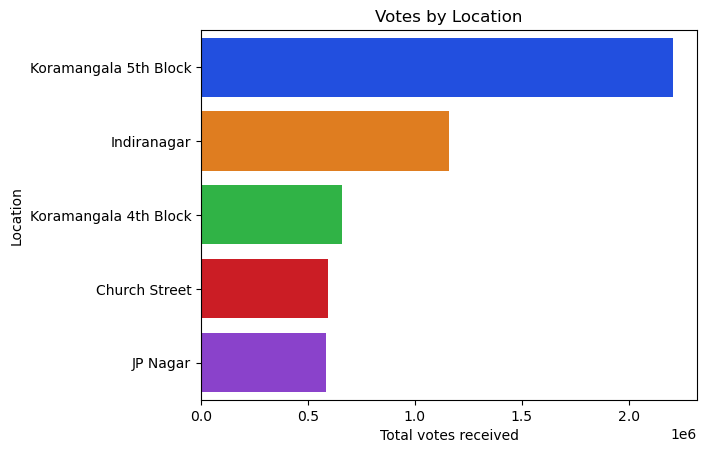

In [202]:
data = df.groupby("location")["votes"].sum().reset_index().sort_values(by="votes",ascending=False)

sns.barplot(
    y="location",
    x="votes",
    data=data.head(),
    palette="bright"
)

plt.xlabel("Total votes received")
plt.ylabel("Location")
plt.title("Votes by Location")


plt.show()

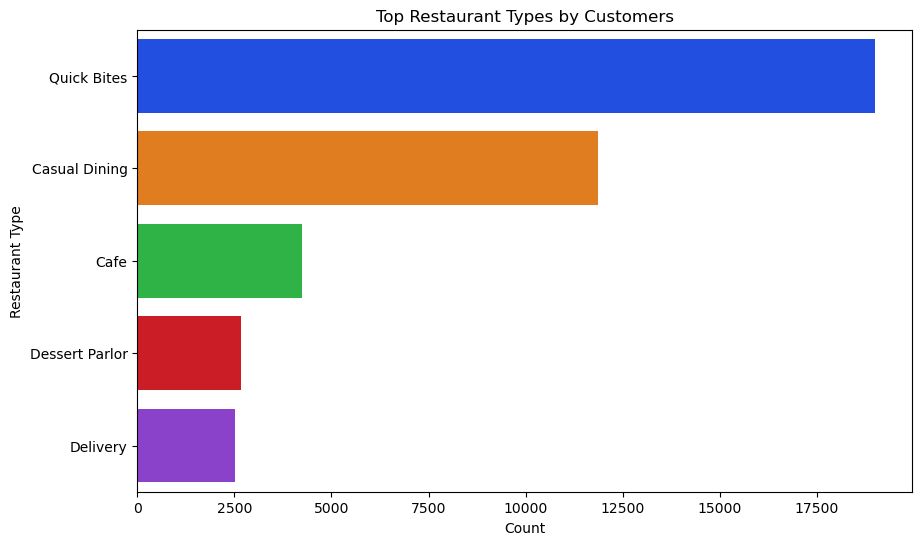

In [203]:
data = df["rest_type"].value_counts().reset_index(name="No. of customers")

plt.figure(figsize=(10, 6))
sns.barplot(
    y="rest_type",
    x="No. of customers",
    data=data.head(),
    palette="bright"
)

plt.ylabel("Restaurant Type")
plt.xlabel("Count")
plt.title("Top Restaurant Types by Customers")


plt.show()

### EDA QUESTION 11] Show the dishes most customers preferred:

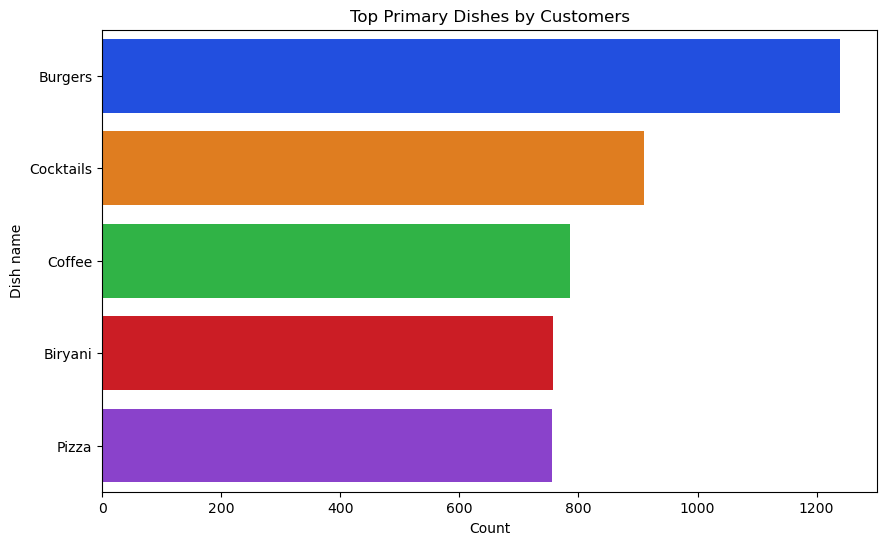

In [204]:
data = df["dish_liked"].value_counts().reset_index(name="No. of customers")
data = data[data["dish_liked"] != "0/5"]

plt.figure(figsize=(10, 6))
sns.barplot(
    y="dish_liked",
    x="No. of customers",
    data=data.head(),
    palette="bright"
)

plt.ylabel("Dish name")
plt.xlabel("Count")
plt.title("Top Primary Dishes by Customers")

plt.show()

### _visualize the above result in the form of pie-chart also:_

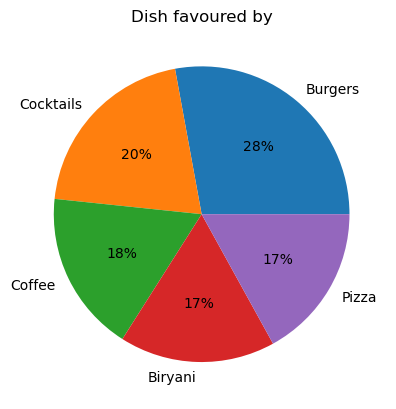

In [205]:
data = df["dish_liked"].value_counts().reset_index(name="No. of customers")
data = data[data["dish_liked"]!="0/5"]

data = data.head()

plt.pie(data["No. of customers"], labels=data["dish_liked"], autopct='%1.0f%%')
plt.title("Dish favoured by")
plt.show()

### EDA QUESTION 12] Relationship between votes and ratings:

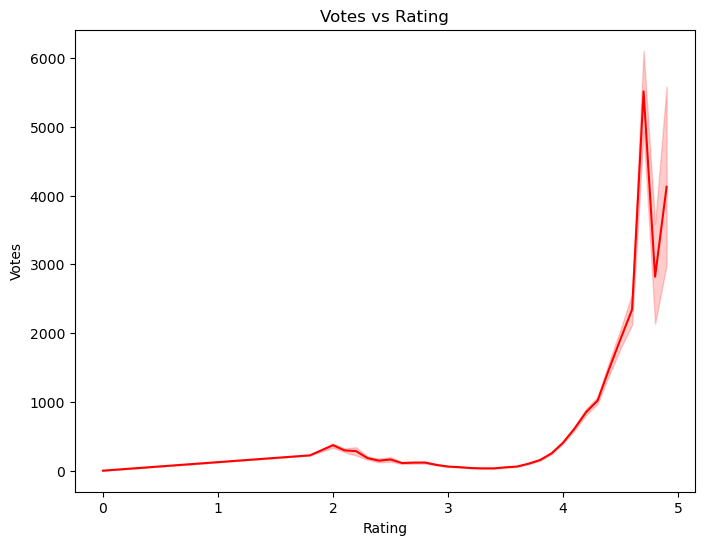

In [206]:
plt.figure(figsize=(8,6))
sns.lineplot(x="rate", y="votes",data=df,color="red")
plt.title("Votes vs Rating")
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.show()


### EDA QUESTION 13] Distribution in Online-orders and restuarant-ratings:

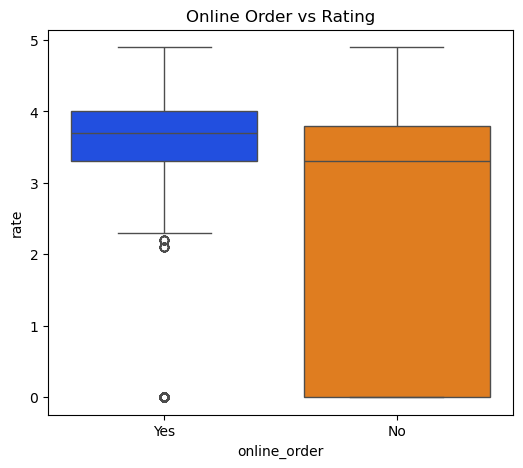

In [207]:
plt.figure(figsize=(6,5))
sns.boxplot(x="online_order", y="rate", data=df,palette="bright")
plt.title("Online Order vs Rating")
plt.show()


### EDA QUESTION 14] Distribution in table-booking options and restuarant-ratings:

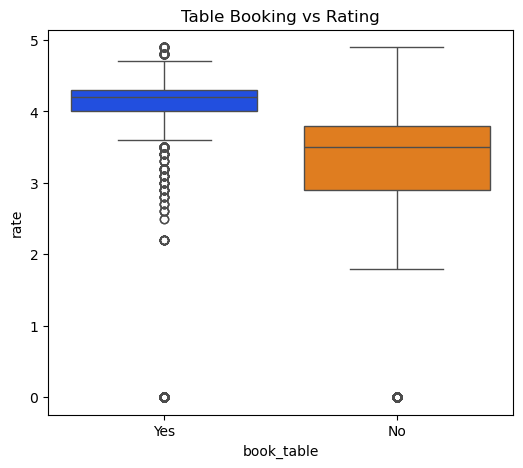

In [208]:
plt.figure(figsize=(6,5))
sns.boxplot(x="book_table", y="rate", data=df,palette="bright")
plt.title("Table Booking vs Rating")
plt.show()


### EDA QUESTION 15] Show the top-10 locations with Highest Ratings (on average):

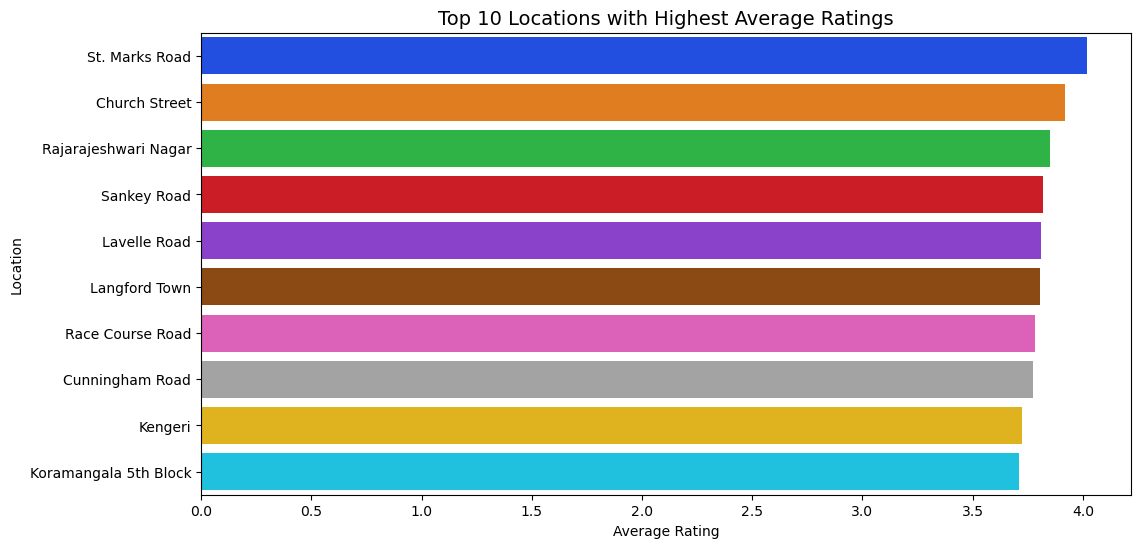

In [209]:
location_ratings = (
    df.groupby("location")["rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=location_ratings.values,
    y=location_ratings.index,
    palette="bright"
)

plt.title("Top 10 Locations with Highest Average Ratings", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Location")

plt.show()


### _A WORDCLOUD OF DISHES LIKED BY CUSTOMERS:_

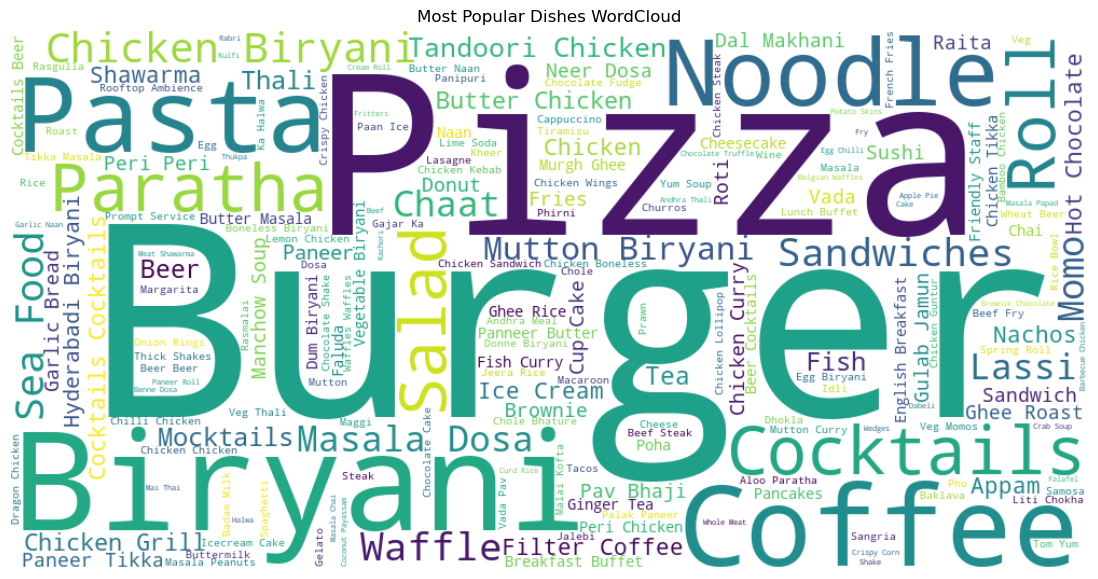

In [210]:
from wordcloud import WordCloud

text = " ".join(df["dish_liked"].astype(str).tolist())
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Popular Dishes WordCloud")
plt.show()


### EDA QUESTION 16] Distribution of Cost Across different restaurant types:

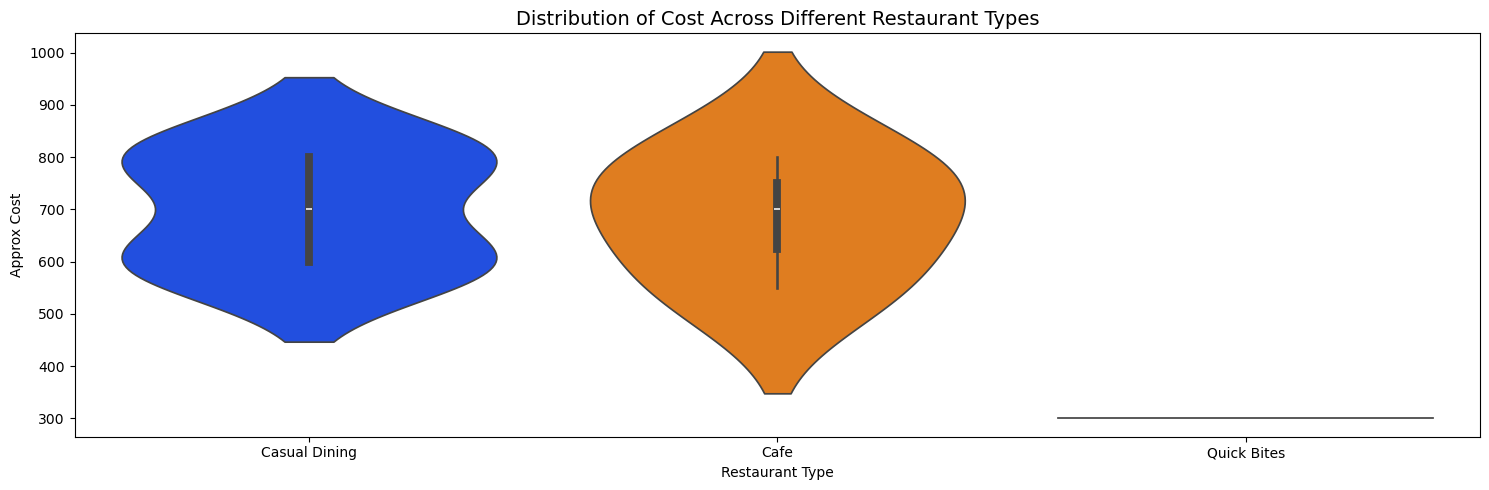

In [211]:
plt.figure(figsize=(15,5))
sns.violinplot(x="rest_type",y="approx_cost(for two people)",data=df.head(10),palette="bright")
plt.title("Distribution of Cost Across Different Restaurant Types", fontsize=14)
plt.xlabel("Restaurant Type")
plt.ylabel("Approx Cost")
plt.tight_layout()

### EDA QUESTION 17] Which restaurant types are the most expensive on average?

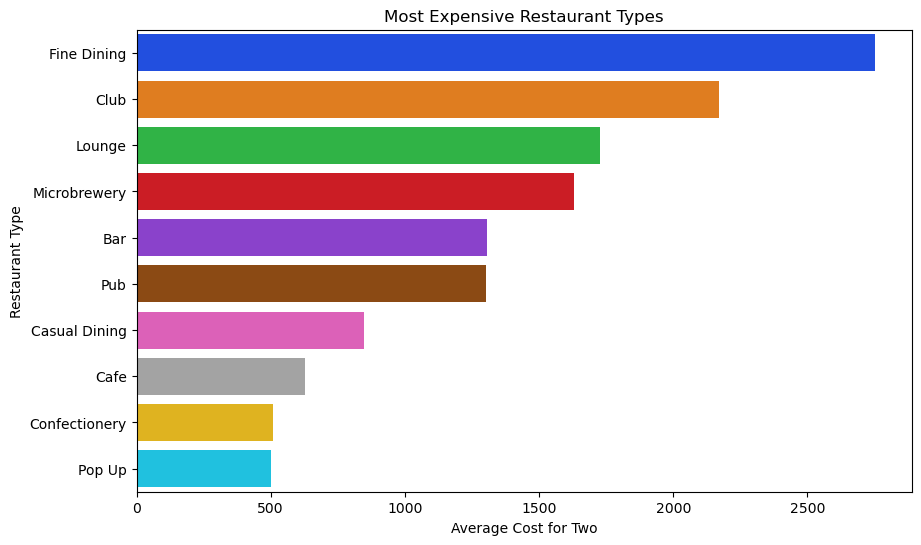

In [212]:
avg_cost_rest_type = df.groupby("rest_type")["approx_cost(for two people)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_cost_rest_type.values, y=avg_cost_rest_type.index,palette="bright")
plt.title("Most Expensive Restaurant Types")
plt.xlabel("Average Cost for Two")
plt.ylabel("Restaurant Type")
plt.show()


### EDA QUESTION 18] Rating distribution for restaurants with and without table booking

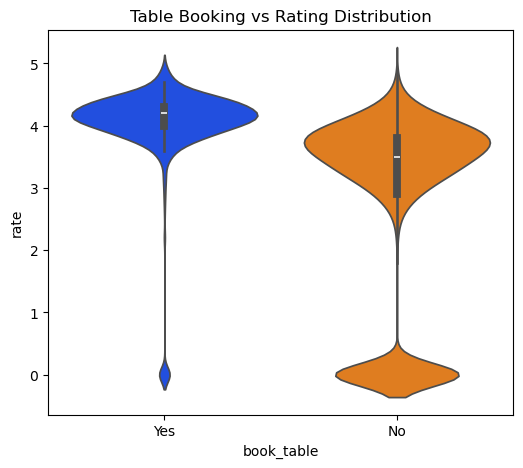

In [213]:
plt.figure(figsize=(6,5))
sns.violinplot(x="book_table", y="rate", data=df,palette="bright")
plt.title("Table Booking vs Rating Distribution")
plt.show()


### EDA QUESTION 19] Which cuisines have the highest average rating? (Top 10)

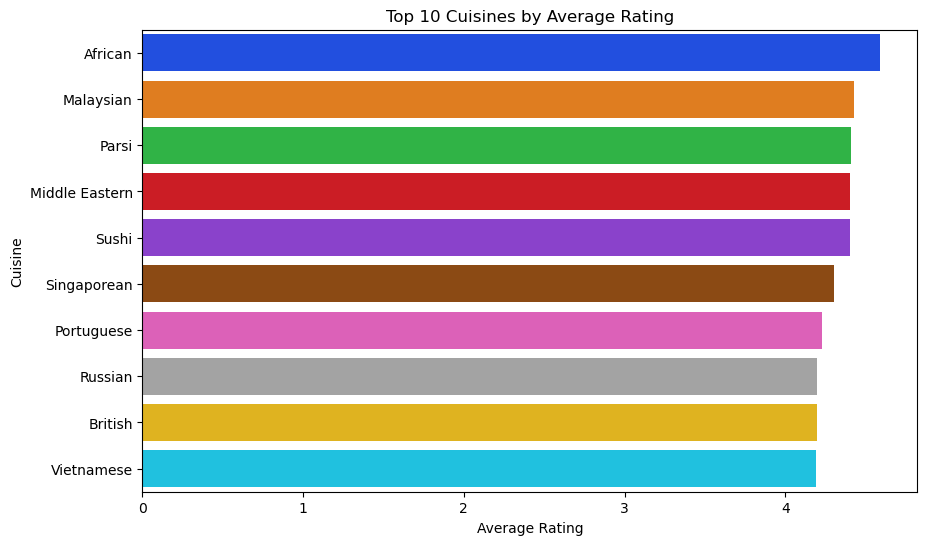

In [214]:
avg_rating_cuisine = df.groupby("cuisines")["rate"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating_cuisine.values, y=avg_rating_cuisine.index,palette="bright")
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()


### EDA QUESTION 20] Relationship between votes and rating (Correlation check)

Correlation :            votes      rate
votes  1.000000  0.276705
rate   0.276705  1.000000


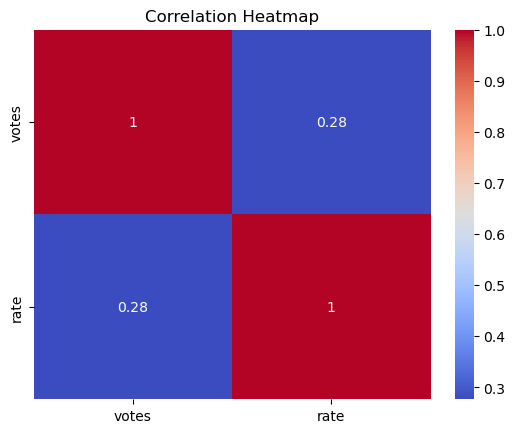

In [215]:
print("Correlation : ",df[['votes', 'rate']].corr())
sns.heatmap(df[['votes', 'rate']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### EDA QUESTION 21] Does online ordering impact average cost?

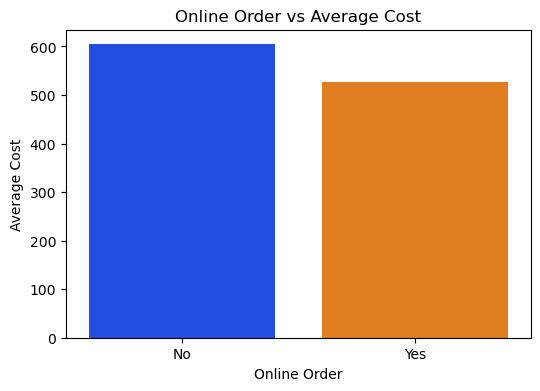

In [216]:
avg_cost_online = (
    df.groupby("online_order")["approx_cost(for two people)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    x="online_order",
    y="approx_cost(for two people)",
    data=avg_cost_online,
    palette="bright"
)

plt.title("Online Order vs Average Cost")
plt.xlabel("Online Order")
plt.ylabel("Average Cost")

plt.show()


### EDA QUESTION 22] Which locations have the cheapest restaurants on average?

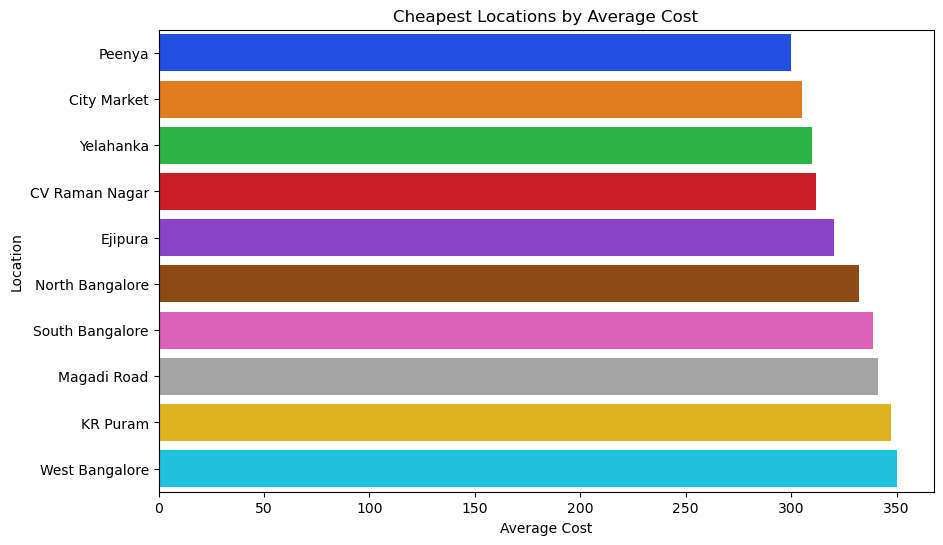

In [217]:
cheap_locations = df.groupby("location")["approx_cost(for two people)"].mean().sort_values().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=cheap_locations.values, y=cheap_locations.index,palette="bright")
plt.title("Cheapest Locations by Average Cost")
plt.xlabel("Average Cost")
plt.ylabel("Location")
plt.show()


##  CONCLUSION OF ALL EDA QUESTIONS

- Most orders were placed from the location **BTM**.

- A majority of customers **preferred placing orders online**.

- Most customers **did not book a table** before visiting the restaurant.

- **Top 5 cuisines preferred by customers:**
  1. North Indian  
  2. South Indian  
  3. Cafe  
  4. Chinese  
  5. Biryani  

- **Top 5 cuisine categories:**
  1. Delivery  
  2. Dine Out  
  3. Desserts  
  4. Cafes  
  5. Drinks & Nightlife  

- **Cities from which the most orders were received:**
  1. BTM  
  2. HSR  
  3. Koramangala 5th Block  
  4. JP Nagar  
  5. Whitefield  

- **Top 5 restaurant types:**
  1. Quick Bites  
  2. Casual Dining  
  3. Cafe  
  4. Dessert Parlor  
  5. Delivery 

- **Most frequently observed restaurant ratings:**
  1. 0.0  
  2. 3.9  
  3. 3.8  
  4. 3.7  
  5. 3.6

- **Locations from where majority of restaurant's ratings were given:**
  1. Koramangala 5th Block
  2. Indiranagar
  3. Koramangala 4th Block
  4. Church Street
  5. JP Nagar

- **Top 5 dishes preferred by customers:**
  1. Burgers  
  2. Cocktails  
  3. Coffee  
  4. Biryani  
  5. Pizza  

- An **increase in the number of votes** generally resulted in an **increase in restaurant ratings**, showing a positive correlation.

- Most **online orders received ratings between 3 and 4** on average, whereas **offline orders received ratings between 0 and 4**.

- Most orders where tables were booked; recieved ratings between 4 to 4.5.

- Most orders where tables were not booked; recieved ratings between 2.8 to 3.8.

- **Top 10 locations with the highest average ratings:**
  1. St. Marks Road  
  2. Church Street  
  3. Rajarajeshwari Nagar  
  4. Sankey Road  
  5. Lavelle Road  
  6. Langford Town  
  7. Race Course Road  
  8. Cunningham Road  
  9. Kengeri  
  10. Koramangala 5th Block  

- **Casual Dining restaurants** charged between **₹500 to ₹890**, showing a **large price variation**.

- **Cafe-type restaurants** charged between **₹450 to ₹800**, also indicating a **wide price range**.

- These are the 5 most expensive restaurant types:
    a) Fine Dining
    b) Club
    c) Lounge
    d) Microbrewery
    e) Bar

- These are the cuisines have the highest average ratings:
    a) African
    b) Malaysian
    c) Parsi
    d) Middle Eastern
    e) Sushi

- On average; these locations have the cheapest restaurants:
    a) Peenya
    b) City Market
    c) Yelahanka
    d) CV Raman Nagar
    e) Ejipura

# MACHINE LEARNING QUESTIONS:

# ML QUESTIONS:

### Q1] Determine whether a person will place an order online based on no. of votes a restaurant has recieved and cost of dining at that restaurant.

Decision Tree Accuracy: 0.7052505966587113


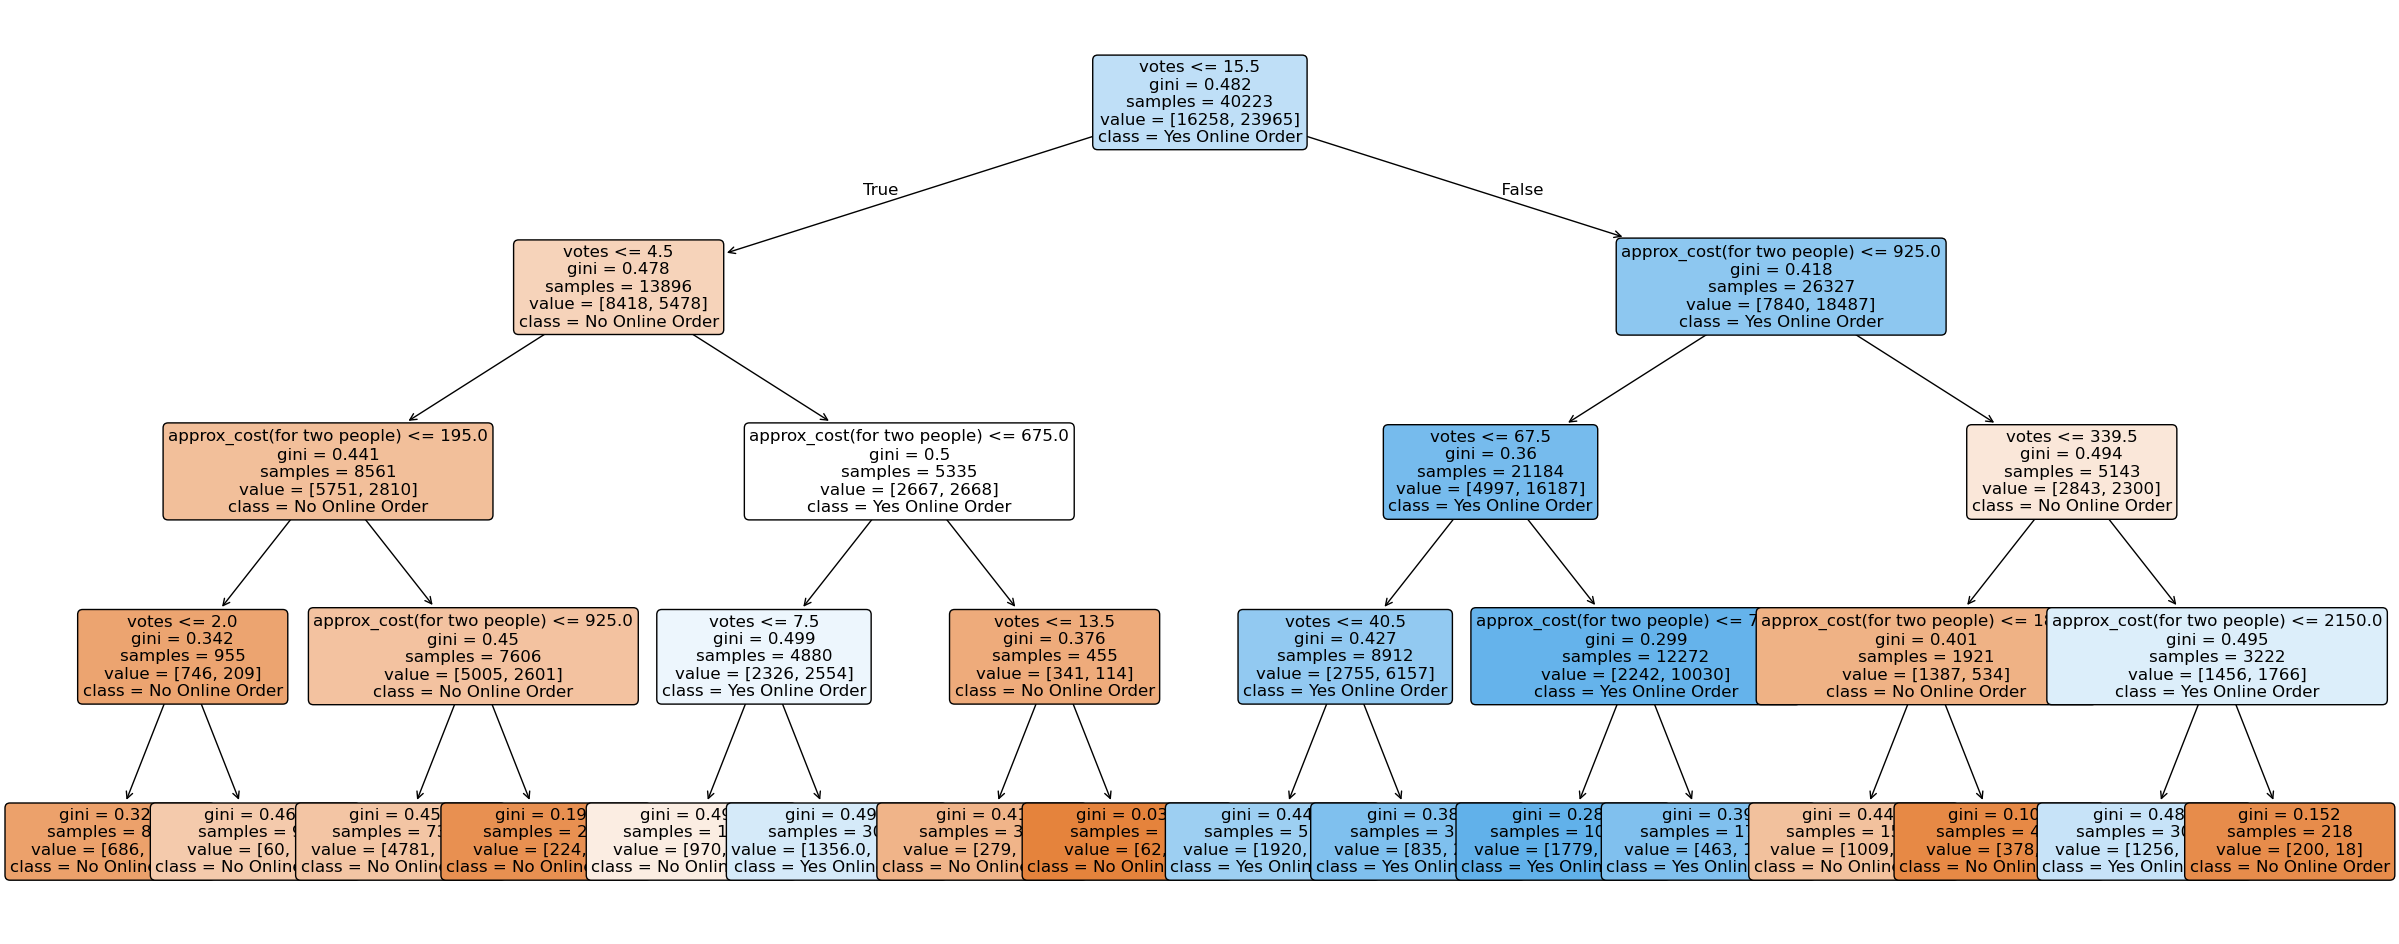

In [218]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# Encode Yes/No to 1/0
df['online_order_encoded'] = df['online_order'].map({'Yes': 1, 'No': 0})

# Features chosen
X = df[['votes', 'approx_cost(for two people)']]
y = df['online_order_encoded']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", acc)


plt.figure(figsize=(30, 12))
plot_tree(
    model,
    feature_names=['votes', 'approx_cost(for two people)'],
    class_names=['No Online Order', 'Yes Online Order'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()


### Conclusion at this point:

This decision tree tries to predict that a person will place an online-order or not based on his'/her's trust (i.e. votes) and affordablity. 
- If votes are low, customers usually avoid online orders unless the cost is very reasonable. 
- If votes are high, customers are more willing to order online, but extremely high prices reduce this likelihood. 


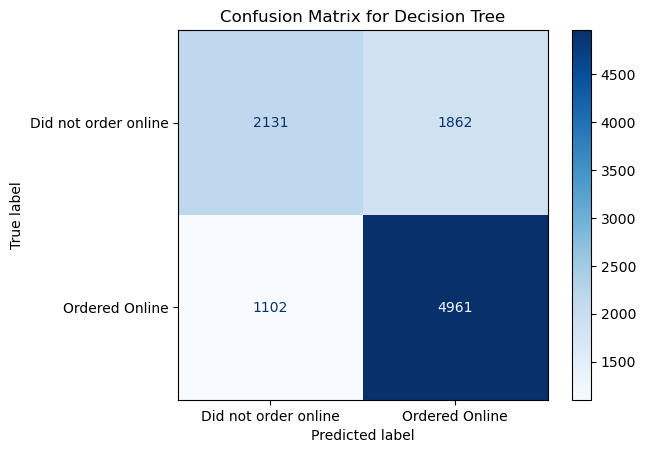

In [219]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

target_names = ['Did not order online', 'Ordered Online']

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Decision Tree")
plt.show()

### CONCLUSION AT THIS POINT:
- Correctly predicted an order to be online = 4961
- Correctly predicted an order to be offline = 2131
- Incorrect predictions for online-order = 1862
- Incorrect predictions for offline-order = 1102


### Q2] Determine whether a person will place an order online based on location of the restaurant and cost of dining at that restaurant.

Decision Tree Accuracy: 0.6228122513922036


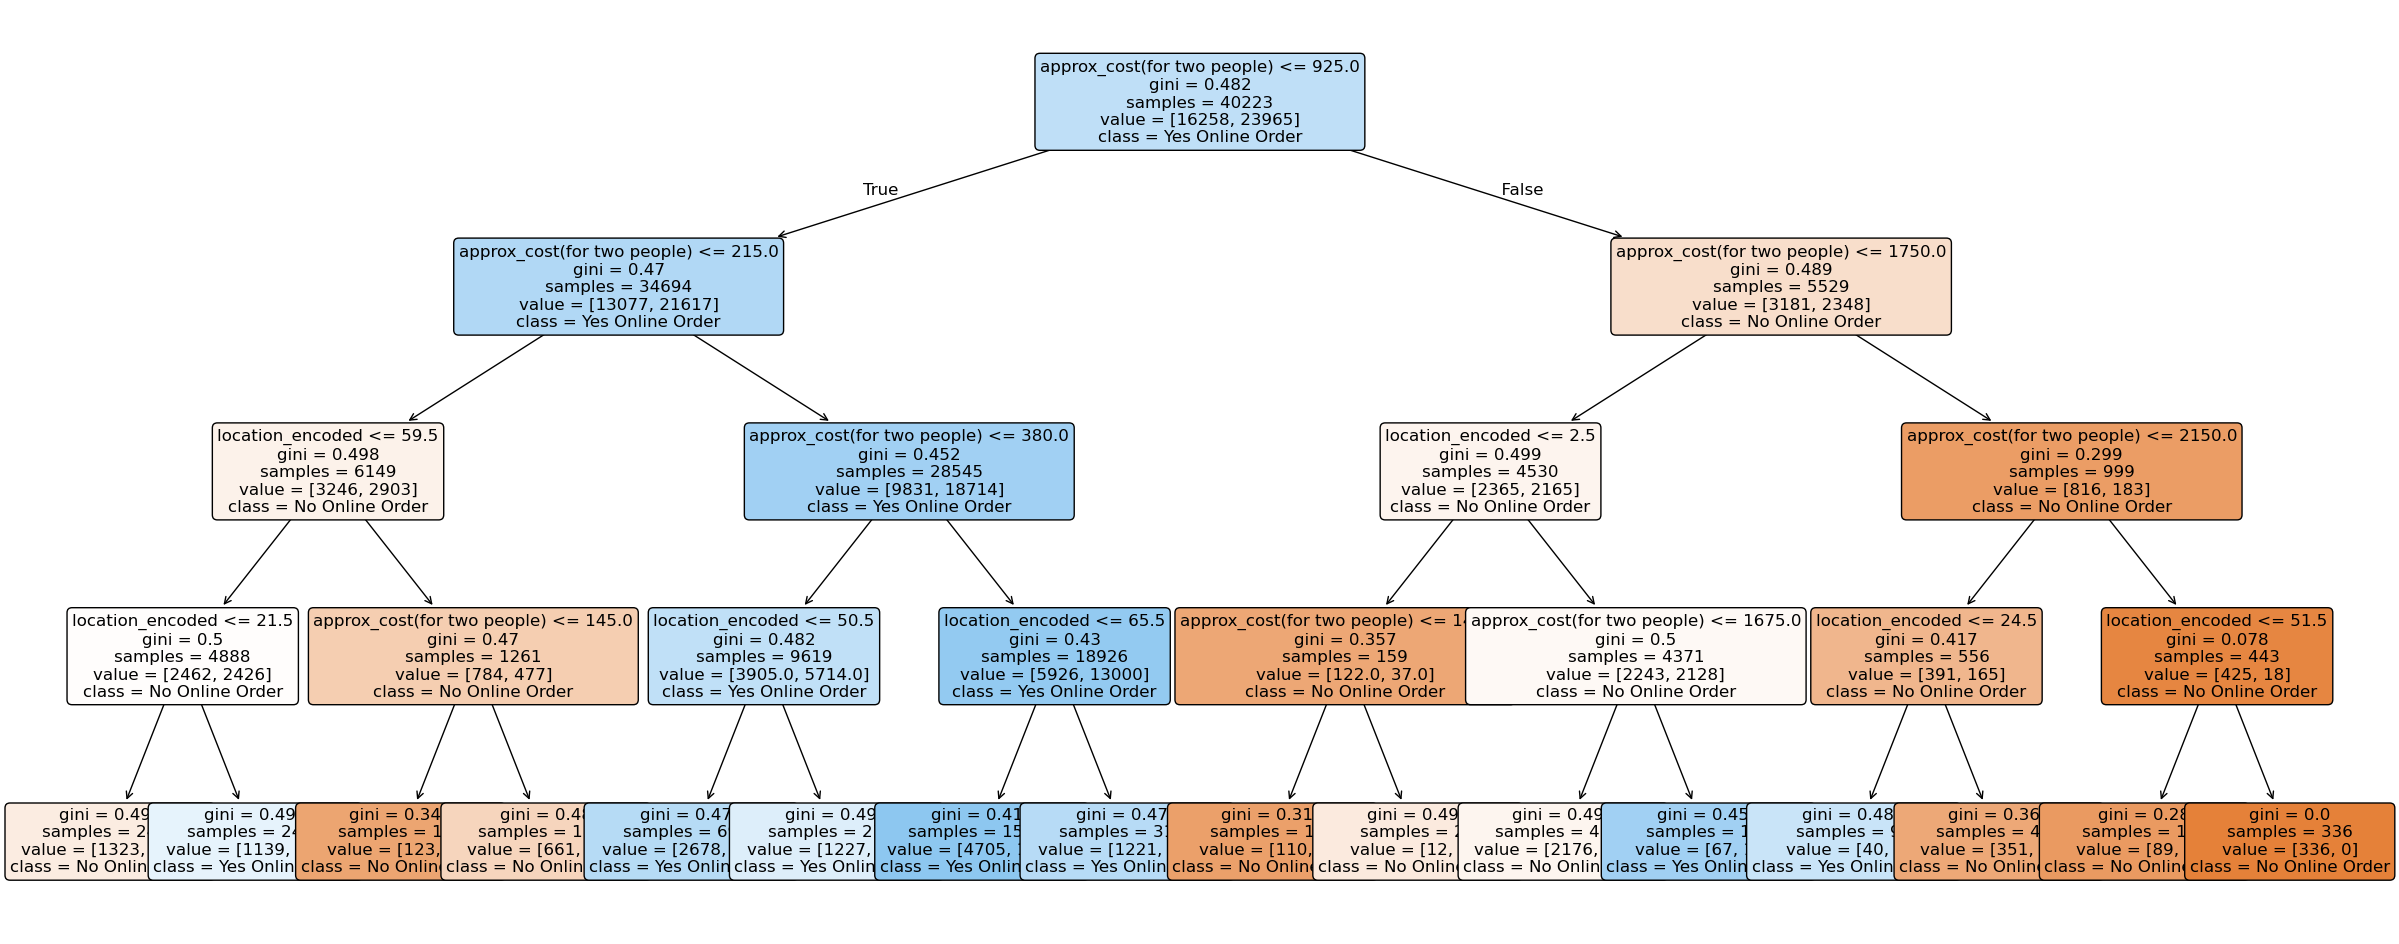

In [220]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location'])


# Features chosen
X = df[['location_encoded', 'approx_cost(for two people)']]
y = df['online_order_encoded']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", acc)


plt.figure(figsize=(30, 12))
plot_tree(
    model,
    feature_names=['location_encoded', 'approx_cost(for two people)'],
    class_names=['No Online Order', 'Yes Online Order'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()


### Conclusion at this point:

This decision tree tries to predict that a person will place an online-order or not based on the restaurant's location and affordablity. 
- For higher cost (more than 2150 INR) people will not prefer placing an online-order (irrespective of the location).
- For lower cost; people may prefer online-order.


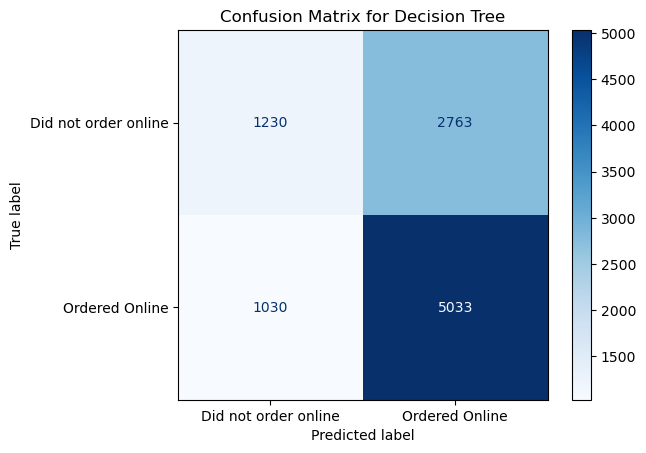

In [221]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

target_names = ['Did not order online', 'Ordered Online']

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Decision Tree")
plt.show()

### CONCLUSION AT THIS POINT:
- Correctly predicted an order to be online = 5033
- Correctly predicted an order to be not online = 1230
- Incorrect predictions for online-order = 2763
- Incorrect predictions for offline-order = 1030


### Q3] Build a Logistic Regression model to predict whether a restaurant offers online ordering (Yes/No) based on its rating, number of votes, and approximate cost for two people.

In [222]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Features and target
X = df[["rate", "votes", "approx_cost(for two people)"]]
y = df["online_order_encoded"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
logr = LogisticRegression(max_iter=1000)
logr.fit(X_train_scaled, y_train)

# Model accuracy
y_pred = logr.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Prediction for a new restaurant
sample = scaler.transform([[4.1, 787, 800]])
result = logr.predict(sample)

if result[0] == 1:
    print("Restaurant offers online ordering")
else:
    print("Restaurant does not offer online ordering")


Accuracy: 0.6828758949880668
Restaurant offers online ordering


### CONCLUSION AT THIS POINT:
Restuarant (with the below details) will get an online-order:
- Rating = 4.1
- Votes received = 787
- Dining cost = 400

### Q4] Build a Linear Regression model to predict the approximate cost for one person at a restaurant based on its rating and number of votes.

In [223]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features and target
X = df[["rate", "votes"]]
y = df["approx_cost(for two people)"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions on test data
y_pred = reg.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

# Example prediction (cost for one person)
predicted_cost_for_two = reg.predict([[3.8, 918]])[0]
print("APPROXIMATE COST OF DINING (one person) =", predicted_cost_for_two / 2)


RMSE: 393.7772517829144
R² Score: 0.19353077681380482
APPROXIMATE COST OF DINING (one person) = 359.79085202854253


### CONCLUSION AT THIS POINT:
Cost of dining for one person is Rs.360 at a restaurant with these details:

- Restaurant name = San Churro Cafe
- Average Rating = 3.8
- Votes = 918

### ZOMATO BUSINESS INSIGHTS:

This analysis brings to light some very informing patterns on restaurant distribution, customer preferences, and pricing across neighborhoods in Bangalore. Cleaning the data guaranteed reliable insights from 50,279 records after handling missing values in ratings, phone numbers, and other fields.

**Top Locations:**

BTM heads the list in terms of the number of restaurants and orders, 
followed by HSR, Koramangala 5th Block, JP Nagar, and Whitefield. 

**Customer Preferences:**

Food preferences include North Indian, South Indian, Cafe, Chinese and Biryani. 
Popular dishes include Burgers, Biryani, Pizza, Coffee, and Cocktails. 
Most customers order online but do not book tables; the rating is 3 to 4 for ordering online 
and 0 to 4 for ordering offline.

**Pricing and Types Casual Dining:**
_≈₹ 500-890 for two; Cafe: ≈₹ 450-800_

Top 5 most expensive restaurant types are: Fine Dining, Club, Lounge, Microbrewery and Bar.
Top 5 places with cheapest dining-cost (on average) are: Peenya, City Market, Yelahanka, CV Raman Nagar and Ejipura.